In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..'))) 

import matplotlib.pyplot as plt
import seaborn as sns
from src import *


plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times"],
    "text.latex.preamble": r"\usepackage{amsmath}\usepackage{mathptmx}",  # Times Roman
    "hatch.linewidth": 3.0,
})
sns.set_context("paper",font_scale=1.5)
sns.set_palette("pastel")

## Check p($a_f|M_{BH}$) marginalized over $\sigma$

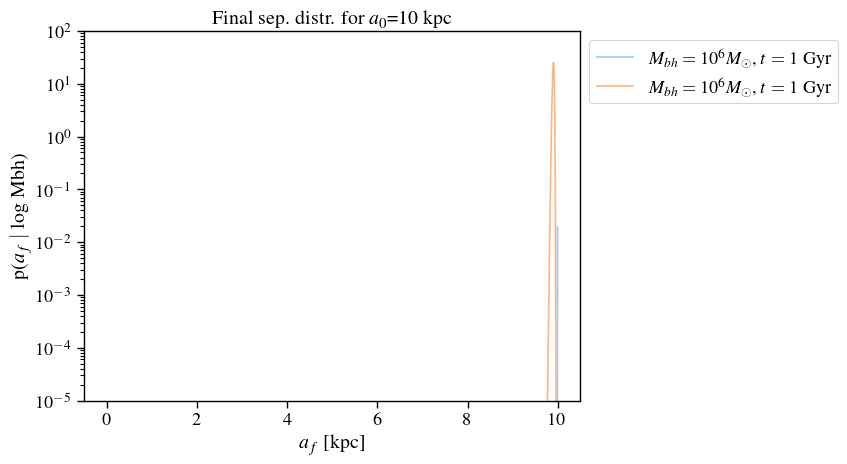

In [ ]:
a0 = 10
a = np.linspace(0,a0,1000)
plt.figure()
plt.plot(a,p_af_sigma(a,mbh = 1e6,t = 1, a0 = 10),label='$M_{bh}=10^6M_\odot$,~$t=1$ Gyr')
# plt.plot(a,p_af_sigma(a,mbh = 1e8,t = 1, a0 = a0),label='$M_{bh}=10^9M_\odot$,~$t=1$ Gyr')
# plt.plot(a,p_af_sigma(a,mbh = 1e6,t = 20, a0 = 10),label='$M_{bh}=10^6M_\odot$,~$t=1$ Gyr')
# plt.plot(a,p_af_sigma(a,mbh = 1e8,t = 10, a0 = a0, R = 0.5),label='$M_{bh}=10^8M_\odot$,~$t=10$ Gyr, R=2')
plt.title(rf"Final sep. distr. for $a_0$={a0} kpc")
plt.xlabel("$a_{f}$ [kpc]")
plt.ylabel("p($a_{f}$ $|$ log Mbh)")
plt.yscale('log')
plt.ylim((1e-5,1e2))
plt.legend(bbox_to_anchor=(1,1));

/home/insepien/dftime/src/pa.py:19: RuntimeWarning: divide by zero encountered in divide
  sigma_star = mbh*t/(gamma/R)/(a0**2-a**2)/200
/home/insepien/dftime/src/pa.py:21: RuntimeWarning: divide by zero encountered in divide
  jacobian = 2*a/(a0**2-a**2)/np.log(10)
/home/insepien/dftime/src/pa.py:22: RuntimeWarning: invalid value encountered in multiply
  return prefactor * exp_term * jacobian
/home/insepien/dftime/src/pa.py:20: RuntimeWarning: invalid value encountered in log10
  exp_term = np.exp(-(np.log10(sigma_star) - 1/beta*logmbh + alpha/beta)**2 / (2*epsilon**2/beta**2))


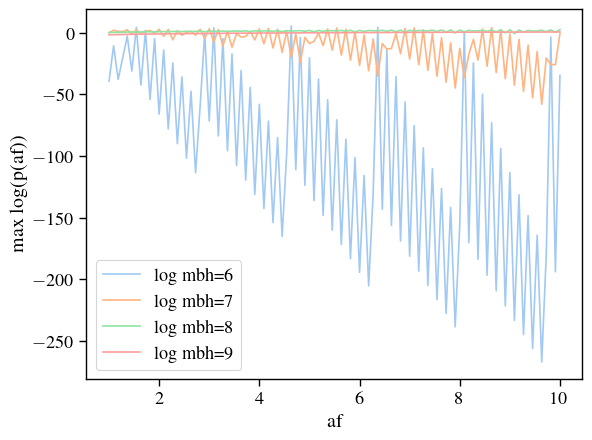

In [35]:
# look at p(a0 at fixed af) -- usually a half spike with varying peak amplitude
a0r = np.linspace(1,20,100)
ar = np.linspace(1,10,100)
for lm in [6,7,8,9]:
    maxp = [np.log(np.nanmax(p_af_sigma(a=a,mbh = 10**lm,t = 1, a0=a0r))) for a in ar]
    plt.plot(ar,maxp,label=f"log mbh={lm}")
plt.xlabel("af")
plt.ylabel("max log(p(af))")
plt.legend();

Check normalization. Note that scipy.quad cannot integrate over a very large range. (quad samples the integration interval and might miss peaks)

In [3]:
quad(p_af_sigma, 0, a0, args=(1e8,1,a0,2))

(0.9999999999999979, 6.962266912397069e-10)

##  Check p($a_f|M_{BH}$) marginalized over $\sigma,a_0$ for uniform $p(a_0)$

/home/insepien/dftime/src/pa.py:19: RuntimeWarning: divide by zero encountered in divide
  sigma_star = mbh*t/(gamma/R)/(a0**2-a**2)/200
/home/insepien/dftime/src/pa.py:20: RuntimeWarning: invalid value encountered in log10
  exp_term = np.exp(-(np.log10(sigma_star) - 1/beta*logmbh + alpha/beta)**2 / (2*epsilon**2/beta**2))
/home/insepien/dftime/src/pa.py:21: RuntimeWarning: invalid value encountered in divide
  jacobian = 2*a/(a0**2-a**2)/np.log(10)


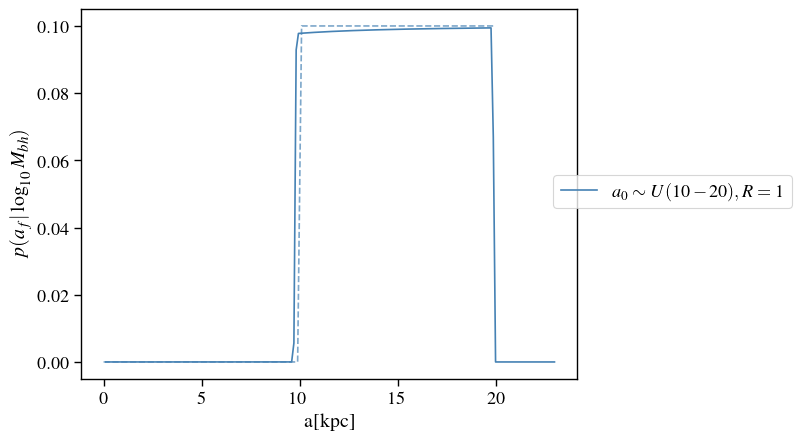

In [3]:
fig,ax = plt.subplots()
plot_pa_unif(10,20,1e8,1,1,ax,"steelblue")

# ax.set_xlim(4,18)
ax.set_xlabel("a[kpc]")
ax.set_ylabel(r"$p(a_f|\log_{10}{M_{bh}})$")
fig.legend(loc="center right",bbox_to_anchor=(1.25,0.5));


Check with Monte Carlo

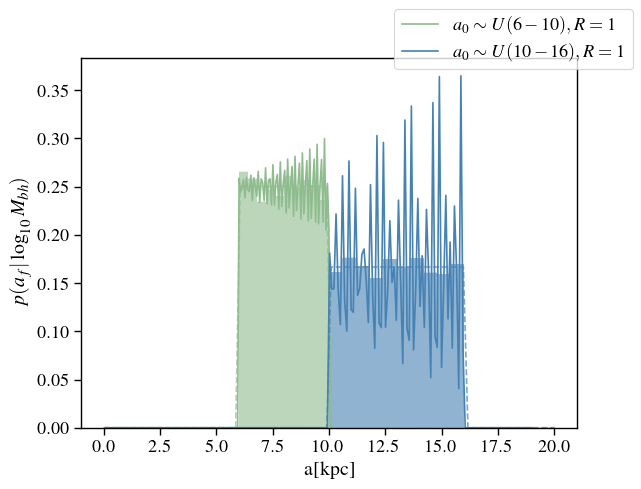

In [28]:
def plot_mc(ax,clr,a0,af):
    ax.hist(af,density=True,color=clr,alpha=0.5)
    ax.hist(a0,density=True,color=clr,alpha=0.2)

def plot_both(amin,amax,mbh,t,R,ax,clr):
    a0,af = af_mc_unif_a0(amin, amax,mbh,t,R,N=5000)
    plot_pa_unif(amin,amax,mbh,t,R,ax,clr)
    plot_mc(ax,clr,a0,af)

fig,ax = plt.subplots()
plot_both(6,10,1e6,1,1,ax,'darkseagreen')
plot_both(10,16,1e6,1,1,ax,'steelblue')

ax.set_xlabel("a[kpc]")
ax.set_ylabel(r"$p(a_f|\log_{10}{M_{bh}})$")
fig.legend();

## test KDE

/home/insepien/dftime/src/pa.py:21: RuntimeWarning: divide by zero encountered in divide
  sigma_star = mbh*t/(gamma/R)/(a0**2-a**2)/200
/home/insepien/dftime/src/pa.py:22: RuntimeWarning: invalid value encountered in log10
  exp_term = np.exp(-(np.log10(sigma_star) - 1/beta*logmbh + alpha/beta)**2 / (2*epsilon**2/beta**2))
/home/insepien/dftime/src/pa.py:23: RuntimeWarning: invalid value encountered in divide
  jacobian = 2*a/(a0**2-a**2)/np.log(10)


''

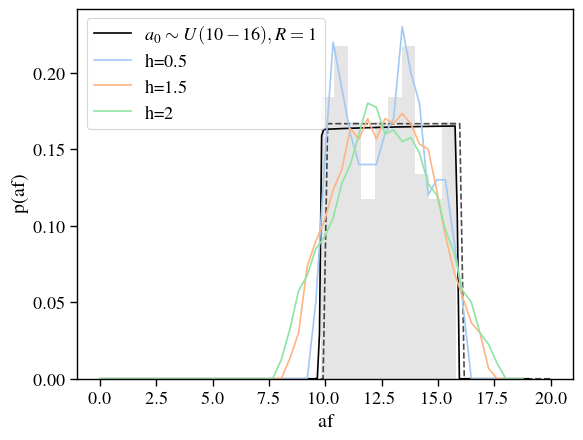

In [6]:
r=1
amin=10
amax=16
np.random.seed(0)

a0_r1,af_r1 = af_mc_unif_a0(amin=amin, amax=amax, R=r, N = 100)

fig,ax = plt.subplots()
ax.hist(af_r1,density=True,color='k',alpha=0.1)
plot_pa_unif(amin=amin, amax=amax, mbh=1e8, t=1, R=r, ax=ax, clr='k')

xplot = np.linspace(0,af_r1.max()+3,50,endpoint=True)
for h in [0.5,1.5,2]:
    # dens = scp_kde(af_r1,xplot,h)
    dens=sklearn_kde(af_r1,xplot,'tophat',h)
    ax.plot(xplot,dens,label=f"h={h}")


ax.set_xlabel("af")
ax.set_ylabel("p(af)")
ax.legend()
;


## building vectorized paf cal

/tmp/ipykernel_10157/1883123124.py:14: RuntimeWarning: divide by zero encountered in divide
  sigma_star = mbh*t/(gamma/R)/(a0**2-a**2)/200
/tmp/ipykernel_10157/1883123124.py:15: RuntimeWarning: invalid value encountered in log10
  exp_term = np.exp(-(np.log10(sigma_star) - 1/beta*logmbh + alpha/beta)**2 / (2*epsilon**2/beta**2))
/tmp/ipykernel_10157/1883123124.py:16: RuntimeWarning: divide by zero encountered in divide
  jacobian = 2*a/(a0**2-a**2)/np.log(10)
/tmp/ipykernel_10157/1883123124.py:16: RuntimeWarning: invalid value encountered in divide
  jacobian = 2*a/(a0**2-a**2)/np.log(10)
/tmp/ipykernel_10157/1883123124.py:17: RuntimeWarning: invalid value encountered in multiply
  return prefactor * exp_term * jacobian
/tmp/ipykernel_10157/106506526.py:16: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  p.append(quad(pa_sigma_a0_unif_integrand, alower, amax, args=(a

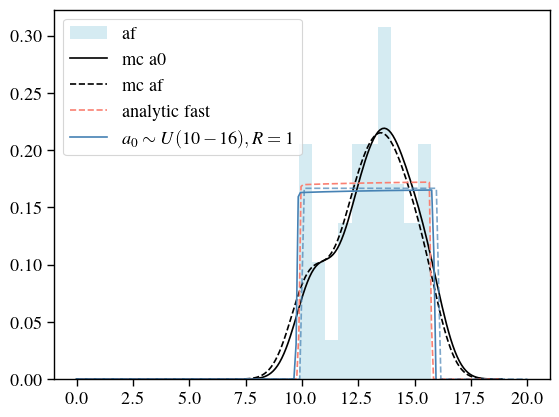

In [ ]:
def paf_analytic_fast(p_a0,a0_samp,mbh,t,R,af_grid=None,
                        Naf=200,Na0=10000, uniform=False):
    if af_grid is None:
        af_grid = np.linspace(0, np.max(a0_samp) + 3, Naf)
    
    # grid for a0
    a0_grid = np.linspace(np.min(af_grid), np.max(af_grid), Na0)
    # meshgrid for a0, af
    AF, A0 = np.meshgrid(af_grid, a0_grid, indexing='ij')

    # grid for p_a0
    if uniform:
        amax = np.max(a0_samp)
        amin = np.min(a0_samp)
        p_a0_vals = np.array([1/(amax-amin)]*len(a0_grid))
        p_a0_vals = np.where((a0_grid<amax) & (a0_grid>amin), 1/(amax-amin), 0)
    else:
        p_a0_vals = p_a0(a0_grid)
    # reshape to mesh grid
    p_a0_grid = p_a0_vals[np.newaxis,:]

    # grid of integrand
    integrand_matrix = p_af_sigma(AF, mbh, t, A0, R) * p_a0_grid
    # cut to integration limit: a0 >= af    
    integrand_matrix = np.where(A0 >= AF, integrand_matrix, 0)
    # integrate
    p_af = simpson(integrand_matrix, a0_grid, axis=1)
    return af_grid, p_af

np.random.seed(0)
amin=10
amax=16
mbh=1e8
t=1
R=1
N=50
# generate mock observations
a0_obs,af_obs = af_mc_unif_a0(amin,amax,mbh,t,R,N)
# estimate p(a0) with kde
p_a0 = scp_kde(a=a0_obs, return_func=True) 
# generate af from KDE p(a0) -- slow with quad int
# af,p_af = paf_analytic(p_a0, a0_obs,mbh,t,R)
# generate af from KDE p(a0) -- fast with vectorization
afF,p_afF = paf_analytic_fast(p_a0, a0_obs,mbh,t,R,uniform=True)
fig,ax = plt.subplots()
# plot to check
plt.hist(af_obs,density=True,color='lightblue',alpha=0.5,label='af')
plt.plot(afF,scp_kde(a0_obs,afF),c='k',label='mc a0')
plt.plot(afF,scp_kde(af_obs,afF),c='k',linestyle="--",label='mc af')
# plt.plot(af,p_af, label='analytic',c='steelblue')
plt.plot(afF,p_afF, label='analytic fast',c='salmon',linestyle="--")
#
plot_pa_unif(amin,amax,mbh,t,R,ax,"steelblue")
plt.legend()



## uniform a0, no selection effect, compare median booted random sample with booted predicted draws

In [ ]:
### 1. initiate some params
a0_pop_min=10
a0_pop_max=16
mbh=1e8
t=1
tR=1
popN=10000
np.random.seed(0)
rates = np.logspace(-1,1,50)

### 2. simulate input data
a0_pop,af_pop = af_mc_unif_a0(amin=a0_pop_min, amax=a0_pop_max, R=tR, N=popN)

### 3. similate predicted p(af)
# define a grid of a for calculating pdfs
ap = np.linspace(0,a0_pop.max()+3,200,endpoint=True)
# estimate observed a0, assuming perfect observation
p_a0_obs = scp_kde(a0_pop,ap,return_func=True)
p_a0_obs_val = p_a0_obs(ap)
# predict p(af) at different rates
p_af_preds = paf_analytic_allrates(p_a0_obs,a0_pop,mbh,t,af_grid=ap,
                        Naf=200,Na0=10000,uniform=True)

### 4. get data dict [obs size] : [median p obs, std p obs, bootstraps of p pred]
obs_sampsize = [10,100,1000]
get_pa_per_obsN_boot = lambda obsN: get_pa_per_obsN(obsN,p_af_preds,af_pop,ap,rates)
res = Parallel(n_jobs=-1)(delayed(get_pa_per_obsN_boot)(obsN) for obsN in obs_sampsize)
dat = {obsN:r for obsN,r in zip(obs_sampsize,res)}

### 5. get divKL dict [obs size] : [# rate x # boot]
acutmin = a0_pop_min
acutmax = a0_pop_max
dat_dkl,dat_cut = cal_dkl_boot_cut(dat,acutmin,acutmax,ap,obs_sampsize)

/home/insepien/dftime/utils/pa.py:21: RuntimeWarning: divide by zero encountered in divide
  sigma_star = mbh*t/(gamma/R)/(a0**2-a**2)/200
/home/insepien/dftime/utils/pa.py:21: RuntimeWarning: divide by zero encountered in divide
  sigma_star = mbh*t/(gamma/R)/(a0**2-a**2)/200
/home/insepien/dftime/utils/pa.py:22: RuntimeWarning: invalid value encountered in log10
  exp_term = np.exp(-(np.log10(sigma_star) - 1/beta*logmbh + alpha/beta)**2 / (2*epsilon**2/beta**2))
/home/insepien/dftime/utils/pa.py:22: RuntimeWarning: invalid value encountered in log10
  exp_term = np.exp(-(np.log10(sigma_star) - 1/beta*logmbh + alpha/beta)**2 / (2*epsilon**2/beta**2))
/home/insepien/dftime/utils/pa.py:21: RuntimeWarning: divide by zero encountered in divide
  sigma_star = mbh*t/(gamma/R)/(a0**2-a**2)/200
/home/insepien/dftime/utils/pa.py:21: RuntimeWarning: divide by zero encountered in divide
  sigma_star = mbh*t/(gamma/R)/(a0**2-a**2)/200
/home/insepien/dftime/utils/pa.py:22: RuntimeWarning: invalid 

/home/insepien/dftime/utils/viz.py:74: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1,-1].legend(loc='upper right',bbox_to_anchor=(1,1.2))


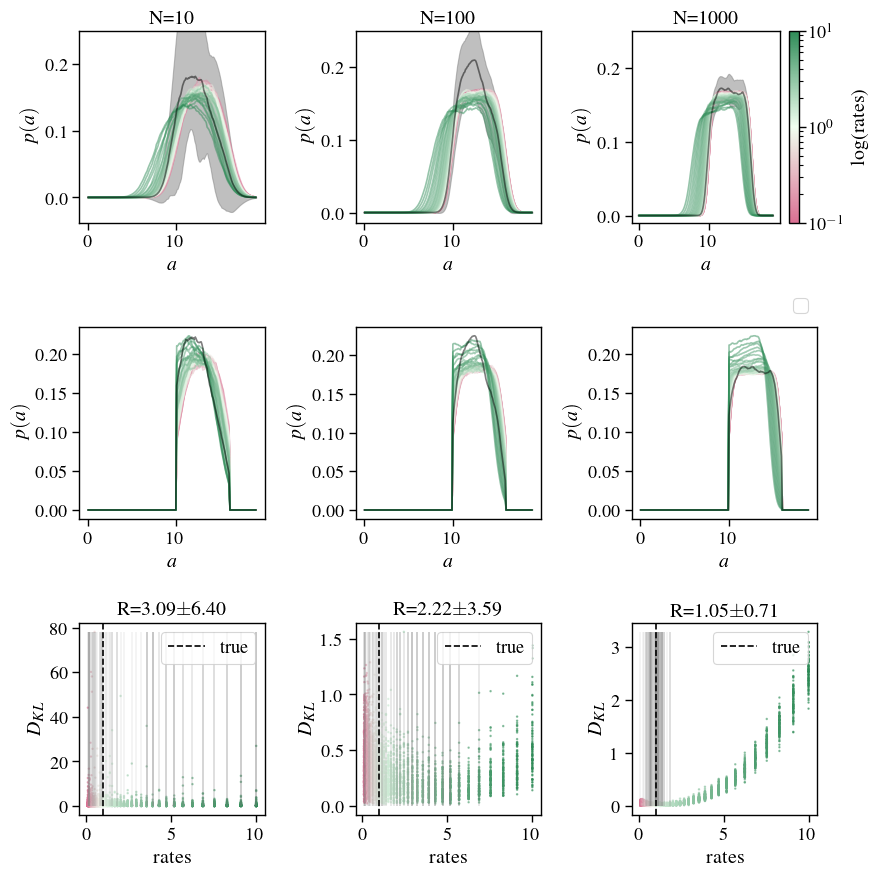

In [5]:
plot_everything(dat,dat_dkl,dat_cut,ap,obs_sampsize)

### unit test

check that estimate p(af) is consistent with true population

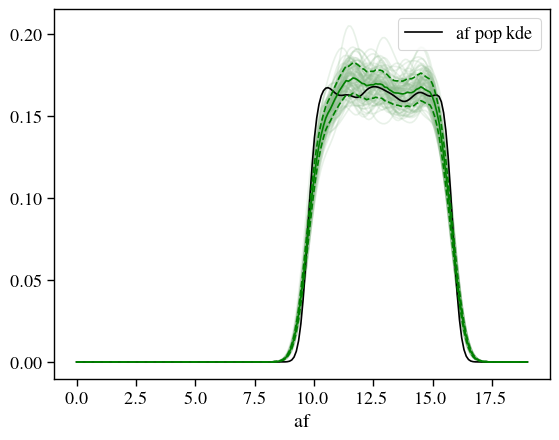

In [8]:
boot_p_afs, medp, stdp = observe_af(1000,af_pop,ap)
fig,ax = plt.subplots()

# plot bootstraps of observed af sample
segs = [np.column_stack([ap, y]) for y in boot_p_afs]
ax.add_collection(LineCollection(segs, colors='darkseagreen', alpha=0.2))
ax.autoscale_view()

# ax.plot(ap, p_af_preds[rates[25]],'b',label=f'r={rates[25]:.2f}')
# ax.plot(ap, p_af_preds[rates[15]],'r',label=f'r={rates[15]:.2f}')
ax.plot(ap, scp_kde(af_pop,ap),label='af pop kde',c='k')

# find med and std of kde
ax.plot(ap,medp,c='g')
ax.plot(ap,medp+stdp,c='g',linestyle='--')
ax.plot(ap,medp-stdp,c='g',linestyle='--')
ax.set_xlabel("af")
ax.legend();

check that samples from p_af_pred is consistent with p_af_pred (for 1 rate)

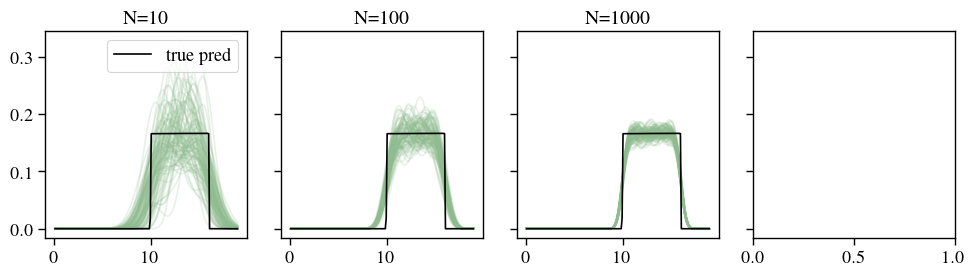

In [13]:
r = rates[10]
samp_pdfs = [sample_pred(rate=r,obsN=obs_sampsize[i],nboot=100,p_af_preds=p_af_preds,ap=ap) for i in range(3)]

fig,axx = plt.subplots(1,3,figsize=(10,3),sharey=True)
for i,ax in zip(range(3),axx):
    samp_pdf = samp_pdfs[i]
    # plot bootstraps of observed af sample
    segs = [np.column_stack([ap, y]) for y in samp_pdf]
    ax.add_collection(LineCollection(segs, colors='darkseagreen', alpha=0.2))
    ax.autoscale_view()
    ax.plot(ap,p_af_preds[r],c='k',label='true pred')
    ax.set_title(f"N={obs_sampsize[i]}")
axx[0].legend()
fig.tight_layout();

****

## Gaussian prior on $a_0$

/home/insepien/dftime/src/pa.py:21: RuntimeWarning: divide by zero encountered in scalar divide
  sigma_star = mbh*t/(gamma/R)/(a0**2-a**2)/200
/home/insepien/dftime/src/pa.py:23: RuntimeWarning: divide by zero encountered in scalar divide
  jacobian = 2*a/(a0**2-a**2)/np.log(10)
/home/insepien/dftime/src/pa.py:24: RuntimeWarning: invalid value encountered in scalar multiply
  return prefactor * exp_term * jacobian
/tmp/ipykernel_14842/1058594198.py:15: IntegrationWarning: Extremely bad integrand behavior occurs at some points of the
  integration interval.
  p.append(quad(pa_sigma_a0_gaus_integrand, a_, aupper, args=(a_,mbh,t,R,amean_ ,std_))[0])


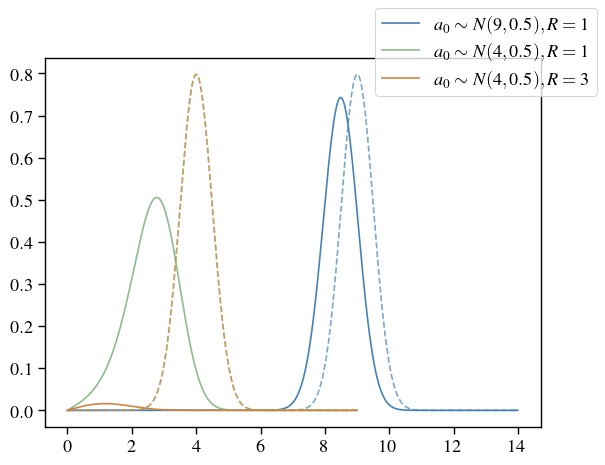

In [7]:
def p_a0_gaussian(a0_ ,amean_ ,std_):
    prefactor = 1/ (np.sqrt(2 * np.pi * std_**2))
    expterm = np.exp(- (a0_ - amean_)**2 / (2 * std_**2))
    return prefactor * expterm

def pa_sigma_a0_gaus_integrand(a0, a, mbh, t, R, amean_ ,std_):
    return p_af_sigma(a, mbh, t, a0, R) * p_a0_gaussian(a0 ,amean_ ,std_)

def pa_sigma_a0_gaus(amean_ ,std_,mbh,t,R):
    aupper = amean_ + std_ * 10
    a = np.linspace(0,aupper,1000)
    prior = p_a0_gaussian(a,amean_,std_)
    p = []
    for a_ in a:
        p.append(quad(pa_sigma_a0_gaus_integrand, a_, aupper, args=(a_,mbh,t,R,amean_ ,std_))[0])
    return a, p, prior

def plot_pa_gaus(amean_ ,std_,mbh,t,R,ax,clr):
    # function for plotting pa, gaussian a0
    # find p(a|mbh)
    a,p,pr = pa_sigma_a0_gaus(amean_ ,std_,mbh,t,R)
    # plot
    ax.plot(a,p,c=clr,label=rf"$a_0\sim N({{{amean_}}},{{{std_}}}),R={R}$")
    ax.plot(a,pr,linestyle="--",c=clr,alpha=0.7)

fig,ax = plt.subplots()
plot_pa_gaus(9,0.5,1e8,2,1,ax,"steelblue")
plot_pa_gaus(4,0.5,1e8,2,1,ax,"darkseagreen")
plot_pa_gaus(4,0.5,1e8,2,3,ax,"peru")
fig.legend();

Check with Monte Carlo

/tmp/ipykernel_17678/2951682623.py:15: IntegrationWarning: Extremely bad integrand behavior occurs at some points of the
  integration interval.
  p.append(quad(pa_sigma_a0_gaus_integrand, a_, aupper, args=(a_,mbh,t,R,amean_ ,std_))[0])
/tmp/ipykernel_17678/3776289179.py:8: RuntimeWarning: invalid value encountered in sqrt
  af = np.sqrt(a0**2 - mbh*t/(gamma*R*sigma))


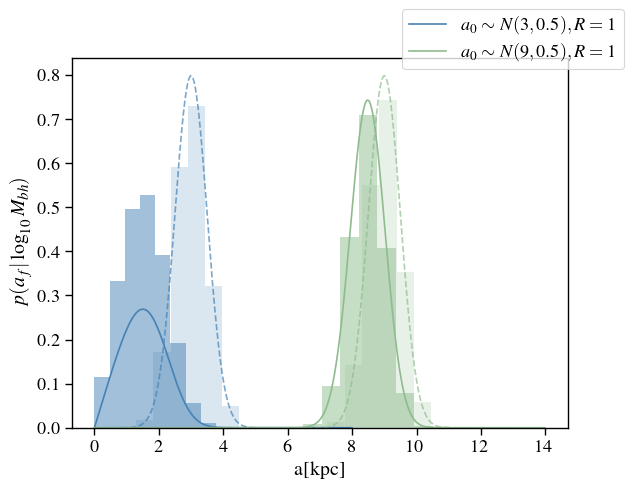

In [20]:
def monte_carlo_gaus_a0(amean_,std_,mbh,t,R,N = 10000000):
    logmbh = np.log10(mbh)
    # sample a0
    a0 = np.random.normal(loc=amean_,scale=std_,size=N)
    # sample sigma
    logsigma = np.random.normal(loc=1/beta*logmbh-alpha/beta,scale=epsilon/beta,size=N)
    sigma = 10**logsigma*200
    af = np.sqrt(a0**2 - mbh*t/(gamma*R*sigma))
    return a0,af

def plot_monte_carlo_gaus_a0(amean_,std_,mbh,t,R,ax,clr):
    a0,af = monte_carlo_gaus_a0(amean_,std_,mbh,t,R)
    # plot
    ax.hist(af,density=True,color=clr,alpha=0.5)
    ax.hist(a0,density=True,color=clr,alpha=0.2)


fig,ax = plt.subplots()
plot_pa_gaus(3,0.5,1e8,2,1,ax,"steelblue")
plot_monte_carlo_gaus_a0(3,0.5,1e8,2,1,ax,"steelblue")

plot_pa_gaus(9,0.5,1e8,2,1,ax,"darkseagreen")
plot_monte_carlo_gaus_a0(9,0.5,1e8,2,1,ax,"darkseagreen")

ax.set_xlabel("a[kpc]")
ax.set_ylabel(r"$p(a_f|\log_{10}{M_{bh}})$")
fig.legend();

## build gaussian a0 measurement, no selection

In [18]:
def paf_analytic_allrates_gaus(a0_pop_mean,a0_pop_std,p_a0,a0_samp,mbh,t,af_grid=None,
                        Naf=200,Na0=10000,gaussian=False,rates=np.logspace(-1,1,50)):
    """given a sample of a0 and precalculated p_a0 function, return a dictionary of predicted p_af for different rates"""
    if af_grid is None:
        af_grid = np.linspace(0, np.max(a0_samp) + 3, Naf)
    
    # grid for a0
    a0_grid = np.linspace(np.min(af_grid), np.max(af_grid), Na0)
    # meshgrid for a0, af
    AF, A0 = np.meshgrid(af_grid, a0_grid, indexing='ij')

    # grid for p_a0
    if gaussian:
        p_a0_vals = p_a0_gaussian(a0_grid,a0_pop_mean,a0_pop_std)
    else:
        p_a0_vals = p_a0(a0_grid)
    # reshape to mesh grid
    p_a0_grid = p_a0_vals[np.newaxis,:]

    def optimize_inner(R):
        """function to parallelize p_af caculation for different rates"""
        # grid of integrand
        integrand_matrix = pa_sigma(AF, mbh, t, A0, R) * p_a0_grid
        # cut integration range
        integrand_matrix = np.where(A0 >= AF, integrand_matrix, 0)
        # integrate
        p_af = simpson(integrand_matrix, a0_grid, axis=1)
        return p_af
    
    # calculate p_af and save as dict[rate]:p_af
    res = Parallel(n_jobs=-1)(delayed(optimize_inner)(r) for r in rates)
    p_af_preds = {r:p for r,p in zip(rates,res)}
    return p_af_preds

In [42]:
### 1. initiate some params
a0_pop_mean=15
a0_pop_std=2
mbh=1e8
t=1
tR=1
popN=10000
np.random.seed(0)
rates = np.logspace(-1,1,50)

### 2. simulate input data
a0_popg,af_popg = monte_carlo_gaus_a0(a0_pop_mean,a0_pop_std,mbh=mbh,t=t, R=tR, N=popN)

### 3. similate predicted p(af)
# define a grid of a for calculating pdfs
apg = np.linspace(0,a0_popg.max()+3,200,endpoint=True)
# estimate observed a0, assuming perfect observation
p_a0_obsg = scp_kde(a0_popg,apg,return_func=True)
p_a0_obs_valg = p_a0_obsg(apg)
# predict p(af) at different rates
p_af_predsg = paf_analytic_allrates_gaus(a0_pop_mean,a0_pop_std,p_a0_obsg,a0_popg,mbh,t,af_grid=apg,
                        Naf=200,Na0=10000)#,gaussian=True)

/home/insepien/dftime/utils/pa.py:21: RuntimeWarning: divide by zero encountered in divide
  sigma_star = mbh*t/(gamma/R)/(a0**2-a**2)/200
/home/insepien/dftime/utils/pa.py:21: RuntimeWarning: divide by zero encountered in divide
  sigma_star = mbh*t/(gamma/R)/(a0**2-a**2)/200
/home/insepien/dftime/utils/pa.py:21: RuntimeWarning: divide by zero encountered in divide
  sigma_star = mbh*t/(gamma/R)/(a0**2-a**2)/200
/home/insepien/dftime/utils/pa.py:21: RuntimeWarning: divide by zero encountered in divide
  sigma_star = mbh*t/(gamma/R)/(a0**2-a**2)/200
/home/insepien/dftime/utils/pa.py:21: RuntimeWarning: divide by zero encountered in divide
  sigma_star = mbh*t/(gamma/R)/(a0**2-a**2)/200
/home/insepien/dftime/utils/pa.py:21: RuntimeWarning: divide by zero encountered in divide
  sigma_star = mbh*t/(gamma/R)/(a0**2-a**2)/200
/home/insepien/dftime/utils/pa.py:21: RuntimeWarning: divide by zero encountered in divide
  sigma_star = mbh*t/(gamma/R)/(a0**2-a**2)/200
/home/insepien/dftime/utils

In [43]:
## 4. get data dict [obs size] : [median p obs, std p obs, bootstraps of p pred]
obs_sampsize = [10,100,1000,5000]
get_pa_per_obsN_boot = lambda obsN: get_pa_per_obsN(obsN, p_af_predsg,af_popg,apg,rates)
resg = Parallel(n_jobs=-1)(delayed(get_pa_per_obsN_boot)(obsN) for obsN in obs_sampsize)
datg = {obsN:r for obsN,r in zip(obs_sampsize,resg)}

/home/insepien/dftime/utils/viz.py:74: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1,-1].legend(loc='upper right',bbox_to_anchor=(1,1.2))


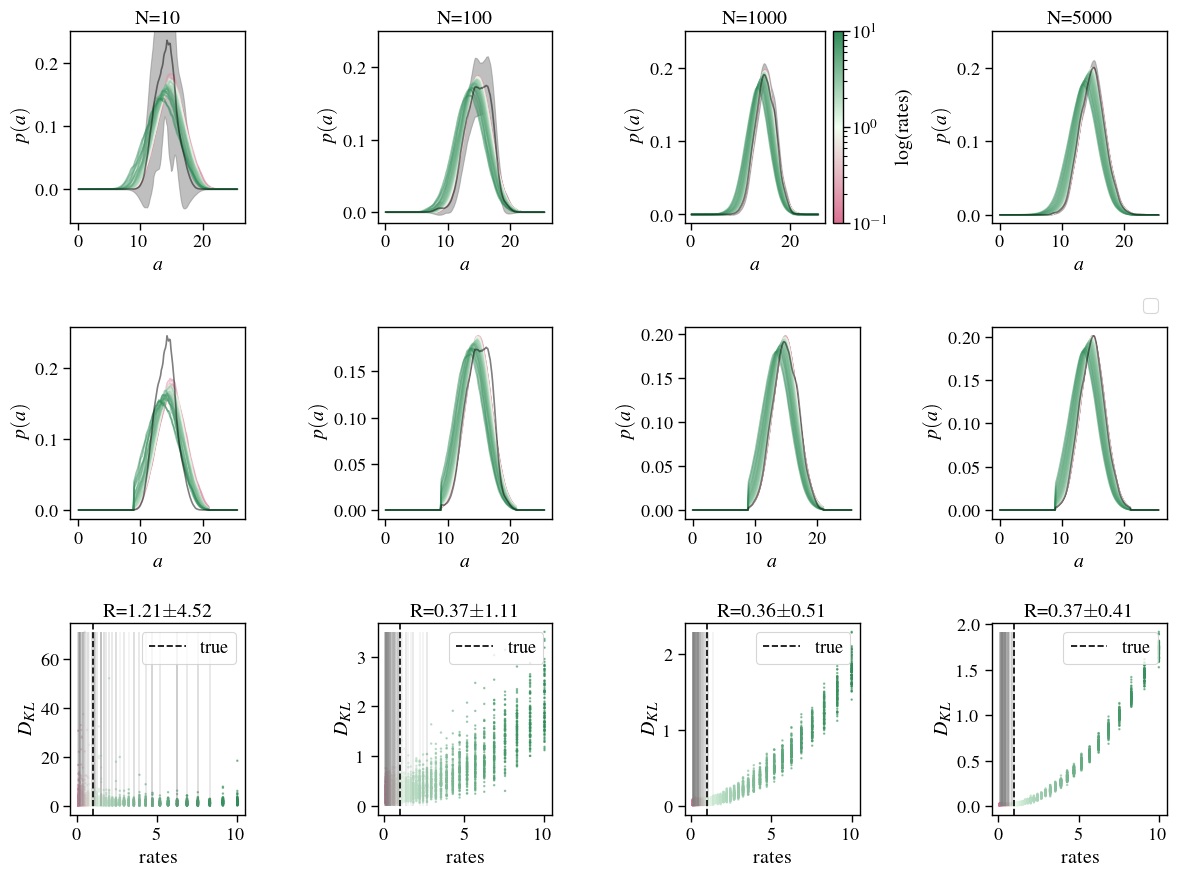

In [44]:
### 5. 
acutming = a0_pop_mean-a0_pop_std*3
acutmaxg = a0_pop_mean+a0_pop_std*3
dat_dklg,dat_cutg = cal_dkl_boot_cut(datg,acutming,acutmaxg,apg,obs_sampsize)

plot_everything(datg,dat_dklg,dat_cutg,apg,obs_sampsize)

### unit test gaus

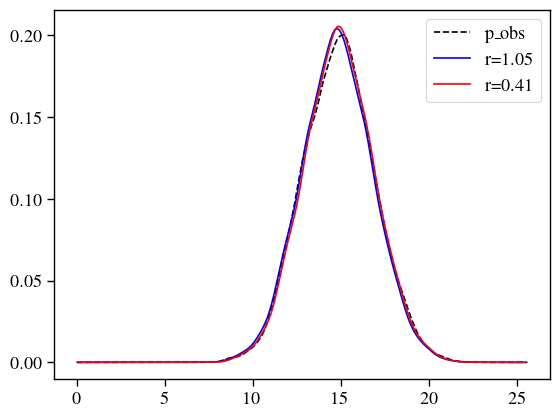

In [46]:
obsN = 5000
fig,ax = plt.subplots()
med_pobs,std_pobs = datg[obsN][:2]
ax.plot(apg,med_pobs,c='k',label='p_obs',linestyle='--')
# ax.fill_between(ap,med_pobs-2*std_pobs,med_pobs+2*std_pobs,color='grey',alpha=0.5)

ax.plot(apg, p_af_predsg[rates[25]],'b',label=f'r={rates[25]:.2f}')
ax.plot(apg, p_af_predsg[rates[15]],'r',label=f'r={rates[15]:.2f}')

ax.autoscale_view()
ax.legend()
# [plt.plot(,dat[1000][-1][rates[25]][i,:]) for i in range(100)];
# plt.plot(ap,dat[1000][0],c='k')
# plt.hist(af_pop,density=True,histtype='step',color='k')

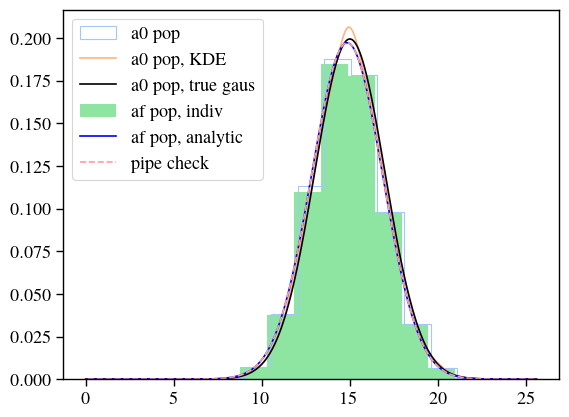

In [ ]:
af_grid=apg
a0_grid = np.linspace(np.min(af_grid), np.max(af_grid), 10000)
# meshgrid for a0, af
AF, A0 = np.meshgrid(af_grid, a0_grid, indexing='ij')
rind = 25
# grid for p_a0
# if gaussian:
p_a0_vals = p_a0_gaussian(a0_grid,a0_pop_mean,a0_pop_std)
p_a0_grid = p_a0_vals[np.newaxis,:]
R = rates[rind]
integrand_matrix = p_af_sigma(AF, mbh, t, A0, R) * p_a0_grid
integrand_matrix = np.where(A0 >= AF, integrand_matrix, 0)
# integrate
p_af = simpson(integrand_matrix, a0_grid, axis=1)

af_pop = af_from_a0(a0_popg, mbh,t,R)
plt.hist(a0_popg,density=True,label='a0 pop',histtype='step')
plt.plot(a0_grid,p_a0_obsg(a0_grid),label='a0 pop, KDE')
plt.plot(a0_grid,p_a0_vals,c='k',label='a0 pop, true gaus')

plt.hist(af_popg,density=True,label='af pop, indiv')
plt.plot(af_grid,p_af,c='b',label='af pop, analytic')
plt.plot(apg, p_af_predsg[rates[rind]],linestyle="--",label='pipe check')
plt.legend();
        

Text(0.5, 1.0, 'p(af_obs)')

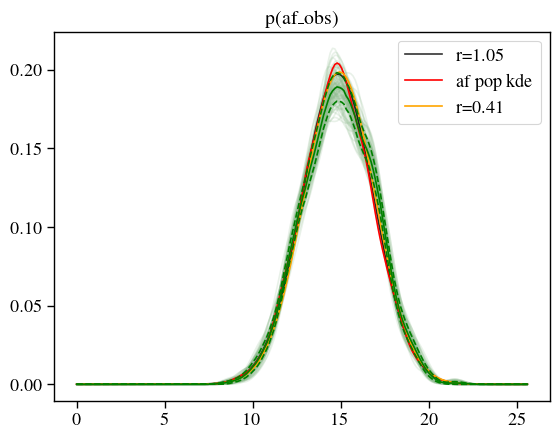

In [34]:
apg = np.linspace(0,a0_popg.max()+3,200,endpoint=True)
boot_p_afs_g,medp_g, stdp_g = observe_af(1000,af_pop=af_popg,ap=apg)

fig,ax = plt.subplots()

# plot bootstraps of observed af sample
segs = [np.column_stack([apg, y]) for y in boot_p_afs_g]
ax.add_collection(LineCollection(segs, colors='darkseagreen', alpha=0.2))
ax.autoscale_view()

ax.plot(apg, p_af_predsg[rates[25]],'k',label=f'r={rates[25]:.2f}',alpha=0.8)
ax.plot(apg,scp_kde(af_popg,apg),c='r',label='af pop kde')
ax.plot(apg, p_af_predsg[rates[15]],c='orange',label=f'r={rates[15]:.2f}')

# find med and std of kde
ax.plot(apg,medp_g,c='g')
ax.plot(apg,medp_g+stdp_g,c='g',linestyle='--')
ax.plot(apg,medp_g-stdp_g,c='g',linestyle='--')

ax.legend();
ax.set_title("p(af_obs)")

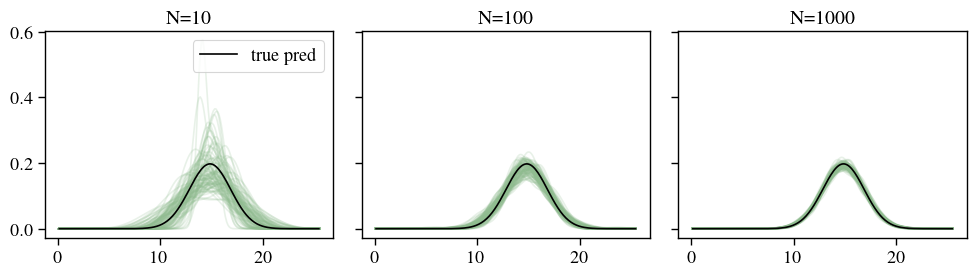

In [35]:
samp_pdfs = [datg[i][-1][rates[25]] for i in obs_sampsize]
fig,axx = plt.subplots(1,3,figsize=(10,3),sharey=True)
for i,ax in zip(range(3),axx):
    samp_pdf = samp_pdfs[i]
    # plot bootstraps of observed af sample
    segs = [np.column_stack([apg, y]) for y in samp_pdf]
    ax.add_collection(LineCollection(segs, colors='darkseagreen', alpha=0.2))
    ax.autoscale_view()
    ax.plot(apg,p_af_predsg[rates[25]],c='k',label='true pred')
    ax.set_title(f"N={obs_sampsize[i]}")
axx[0].legend()
fig.tight_layout();

(array([ 5.,  9., 29., 15.,  9., 16.,  6.,  7.,  3.,  1.]),
 array([0.01185431, 0.02162839, 0.03140246, 0.04117654, 0.05095061,
        0.06072469, 0.07049876, 0.08027284, 0.09004692, 0.09982099,
        0.10959507]),
 [<matplotlib.patches.Polygon at 0x7f25fba31510>])

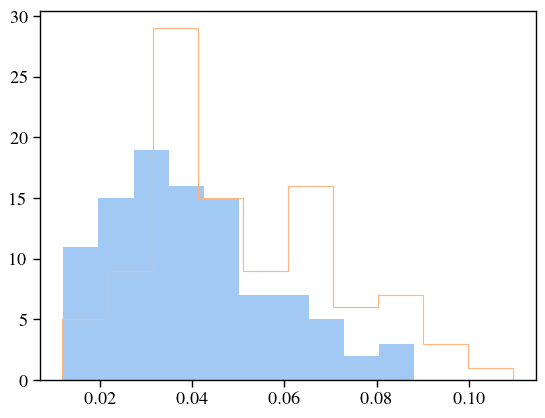

In [36]:
p_pred_boot_cutnorm=datg[1000][-1][rates[15]]
eps = 1e-10 
plt.hist(np.sum(medp_g * np.log((medp_g + eps) / (p_pred_boot_cutnorm + eps)), axis=1))

p_pred_boot_cutnorm=datg[1000][-1][rates[25]]
plt.hist(np.sum(medp_g * np.log((medp_g + eps) / (p_pred_boot_cutnorm + eps)), axis=1),histtype='step')